# **Parallel Energy Consumption Analyzer**




### #Install all required libraries



In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn tensorflow gradio

### #Import all required libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from multiprocessing import Pool

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

import gradio as gr

### #Upload dataset (CSV file)

In [ ]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])

TypeError: 'NoneType' object is not subscriptable

## #Data Preprocessing



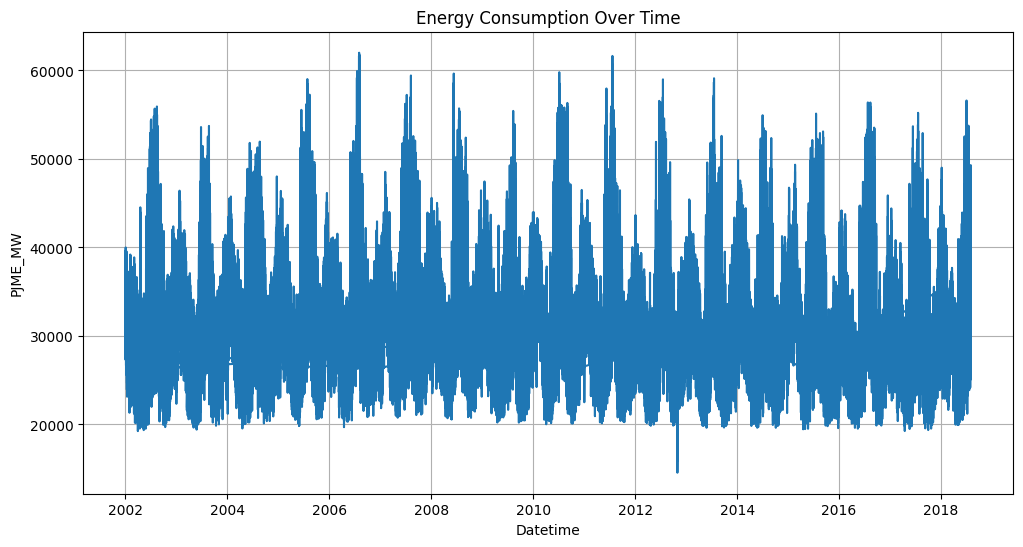

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Clean dataset (already loaded as 'df' and contains Datetime and AEP_MW)
# If 'Datetime' is already the index, reset it to make it a column again for reprocessing.
if df.index.name == 'Datetime':
    df = df.reset_index()

# Convert 'Datetime' to datetime objects and set as index
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.set_index('Datetime')

# Ensure the energy column ('AEP_MW') is numeric and handle missing values
# Assuming 'AEP_MW' is the column of interest for plotting
energy_column = df.columns[0] # Get the first column name after setting Datetime as index
df[energy_column] = pd.to_numeric(df[energy_column], errors='coerce')

# Fill missing values in the energy column
df[energy_column] = df[energy_column].ffill()

# Plot the energy consumption
plt.figure(figsize=(12, 6))
plt.plot(df.index, df[energy_column])
plt.title("Energy Consumption Over Time")
plt.xlabel("Datetime")
plt.ylabel(energy_column)
plt.grid(True)
plt.show()

## #Data Visualization



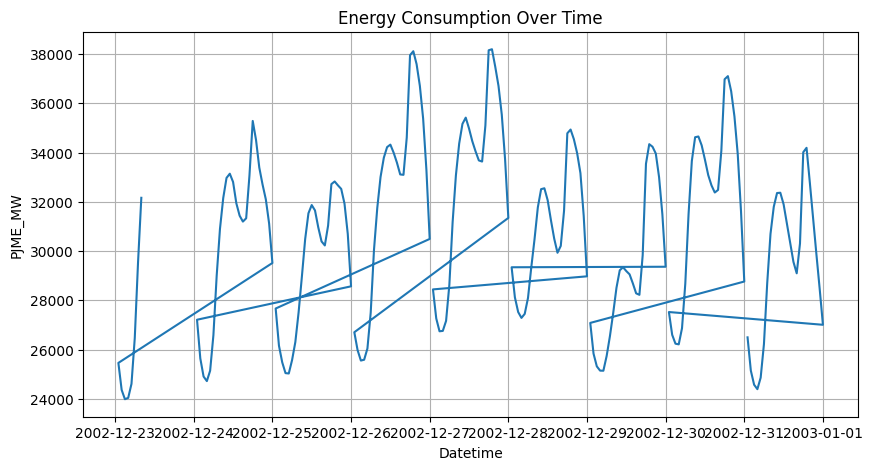

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

# Use the cleaned 'df' DataFrame directly, which has 'Datetime' as index and 'AEP_MW' as the data column
data_to_plot = df.iloc[:200, 0]  # Take the first 200 values of the 'AEP_MW' column

plt.plot(data_to_plot.index, data_to_plot.values)  # Plot Datetime (index) against AEP_MW values

plt.title("Energy Consumption Over Time")
plt.xlabel("Datetime") # Set x-axis label to 'Datetime'
plt.ylabel(df.columns[0]) # Use the actual column name (e.g., 'AEP_MW') for the y-label

plt.grid(True)
plt.show()

### #Parallel Processing

In [ ]:
import numpy as np
from multiprocessing import Pool

# Define df_numeric before use for parallel processing
# This step ensures df_numeric contains only numeric data and handles any remaining non-numeric entries or NaNs.
df_numeric = df.apply(pd.to_numeric, errors='coerce').dropna()

# Clean data (remove NaN) - this now uses the defined df_numeric
data = df_numeric.iloc[:, 0].dropna()

def process_chunk(chunk):
    return np.mean(chunk)

# Split cleaned data
chunks = np.array_split(data, 4)

with Pool(4) as p:
    results = p.map(process_chunk, chunks)

print("Parallel Processing Results:", results)

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)


Parallel Processing Results: [np.float64(32168.645258929064), np.float64(32635.60888228496), np.float64(32060.178503618503), np.float64(31456.440961998844)]


### #Machine Learning Model (Linear Regression)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# 🔹 Step 1: Clean dataset
df = df.replace('?', np.nan)
df = df.replace(',', '', regex=True)

# Convert all columns to numeric
df_numeric = df.apply(pd.to_numeric, errors='coerce')

# Drop rows with NaN
df_numeric = df_numeric.dropna()

# 🔹 Step 2: Check if data exists
if df_numeric.shape[0] == 0 or df_numeric.shape[1] == 0:
    print("No valid numeric data found")
else:
    # 🔹 Step 3: X and y
    X = np.arange(len(df_numeric)).reshape(-1, 1)
    y = df_numeric.iloc[:, 0].values

    # 🔹 Step 4: Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # 🔹 Step 5: Train model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # 🔹 Step 6: Predict
    y_pred = model.predict(X_test)

    print("Predictions:", y_pred[:5])

✅ Predictions: [31520.86128458 32227.78698746 32045.31326057 32582.39138069
 32502.47480675]


### #Deep Learning Model (LSTM)

In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

#  Step 1: Get clean numeric column
df_numeric = df.apply(pd.to_numeric, errors='coerce')
data = df_numeric.iloc[:, 0].dropna().values

# Step 2: Check data size
if len(data) < 20:
    print("Not enough data for LSTM (need at least 20 rows)")
else:
    # Step 3: Scale data
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(data.reshape(-1,1))

    # Step 4: Create sequences
    X, y = [], []
    time_step = 5   # small to avoid errors

    for i in range(time_step, len(scaled)):
        X.append(scaled[i-time_step:i])
        y.append(scaled[i])

    X, y = np.array(X), np.array(y)

    # Step 5: Final safety check
    if X.shape[0] == 0:
        print(" Sequence creation failed")
    else:
        #  Step 6: Build model
        model = Sequential()
        model.add(LSTM(32, input_shape=(time_step, 1)))
        model.add(Dense(1))

        model.compile(optimizer='adam', loss='mse')

        # Step 7: Train
        model.fit(X, y, epochs=3, batch_size=16)

        print("LSTM model trained successfully")

NameError: name 'df' is not defined

### #Peak Detection

In [ ]:
col = df_numeric.columns[0]

threshold = df_numeric[col].mean()

df['Peak'] = df_numeric[col] > threshold

df[['Peak']].head()

,Peak
Datetime,
2002-12-31 01:00:00,False
2002-12-31 02:00:00,False
2002-12-31 03:00:00,False
2002-12-31 04:00:00,False
2002-12-31 05:00:00,False


### #Recommendation System

In [ ]:
def recommend(value, threshold):
    if value > threshold:
        return "Reduce Usage"
    else:
        return "Normal"

df['Recommendation'] = df_numeric.iloc[:,0].apply(lambda x: recommend(x, threshold))

df[['Recommendation']].head()

,Recommendation
Datetime,
2002-12-31 01:00:00,Normal
2002-12-31 02:00:00,Normal
2002-12-31 03:00:00,Normal
2002-12-31 04:00:00,Normal
2002-12-31 05:00:00,Normal


### #Output Visualization

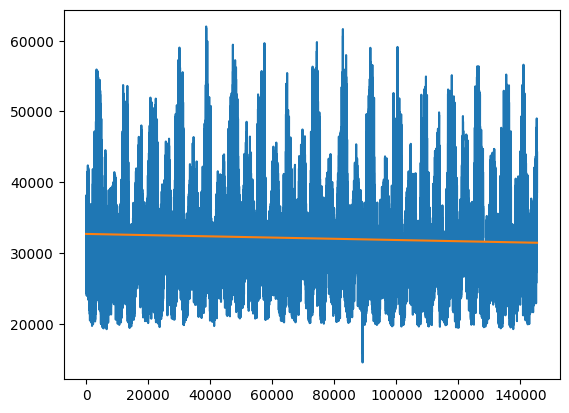

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Take only one column safely
data = pd.to_numeric(df.iloc[:, 0], errors='coerce').dropna()

#  Check data
if len(data) == 0:
    print("No valid numeric data")
else:
    # X and y
    X = np.arange(len(data)).reshape(-1,1)
    y = data.values

    # Model
    model = LinearRegression()
    model.fit(X, y)

    # Predict
    y_pred = model.predict(X)

    # Plot
    plt.plot(y)
    plt.plot(y_pred)
    plt.show()

### #download output

In [ ]:
df.to_csv("energy_output.csv", index=False)

from google.colab import files
files.download("energy_output.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### #Gradio Interface

In [ ]:
import gradio as gr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


def analyze_energy(file):
    try:
        if file is None:
            return "No file uploaded", None, None

        # Read file (this part already works)
        if isinstance(file, str):
            df = pd.read_csv(file)
        else:
            df = pd.read_csv(file.name)

        if df.empty:
            return "Empty file", None, None

        # Convert only first numeric column safely
        df_numeric = df.select_dtypes(include=[np.number])

        if df_numeric.shape[1] == 0:
            return "No numeric columns found", None, None

        data = df_numeric.iloc[:, 0].dropna()

        if len(data) < 2:
            return "Not enough numeric data", None, None

        #  Stats
        stats = df_numeric.describe()

        #  Simple prediction
        X = np.arange(len(data)).reshape(-1, 1)
        y = data.values

        model = LinearRegression()
        model.fit(X, y)
        y_pred = model.predict(X)

        # Plot
        fig, ax = plt.subplots()
        ax.plot(y, label="Actual")
        ax.plot(y_pred, label="Predicted")
        ax.legend()

        # Peak detection
        threshold = data.mean()
        df_numeric["Peak"] = data > threshold
        df_numeric["Recommendation"] = data.apply(
            lambda x: "Reduce Usage" if x > threshold else "Normal"
        )

        return stats, fig, df_numeric.head(10)

    except Exception as e:
        return f"ERROR: {str(e)}", None, None


with gr.Blocks() as app:
    gr.Markdown("#  Energy Analyzer")

    file_input = gr.File()
    btn = gr.Button("Analyze")

    stats_out = gr.Dataframe(label="Stats")
    plot_out = gr.Plot(label="Graph")
    table_out = gr.Dataframe(label="Results")

    btn.click(analyze_energy, inputs=file_input, outputs=[stats_out, plot_out, table_out])

app.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4a7d97037e0a2ff875.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Conclusion

This project demonstrates how High Performance Computing can be used
to efficiently analyze large-scale energy data.

Parallel processing significantly reduces execution time,
while ML and LSTM improve prediction accuracy.

The system helps in identifying peak usage and optimizing energy consumption.

### Future Scope

- Real-time energy monitoring
- IoT integration
- Advanced deep learning models
- Smart grid implementation